In [1]:
#%pip install vaderSentiment
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
path='Zepto_Reviews.csv'
df=pd.read_csv(path)

In [2]:
s_obj= SentimentIntensityAnalyzer()
compound_scores=[]
for i in range(len(df['Review Text'])):
    pol_score=s_obj.polarity_scores(df['Review Text'][i])
    if pol_score['compound'] >= 0.75:
        compound_scores.append('Extremely Satisfied')
    elif  0.75> pol_score['compound'] >= 0.25:
        compound_scores.append('Satisfied')
    elif 0.25 > pol_score['compound'] >= -0.25:
        compound_scores.append('Neutral')
    elif -0.25 > pol_score['compound'] >= -0.75:
        compound_scores.append('Dissatisfied')
    else:
        compound_scores.append('Extremely Dissatisfied')
#print(compound_scores)
df['Polarity Scores'] = compound_scores
df.to_csv(path, index=False)

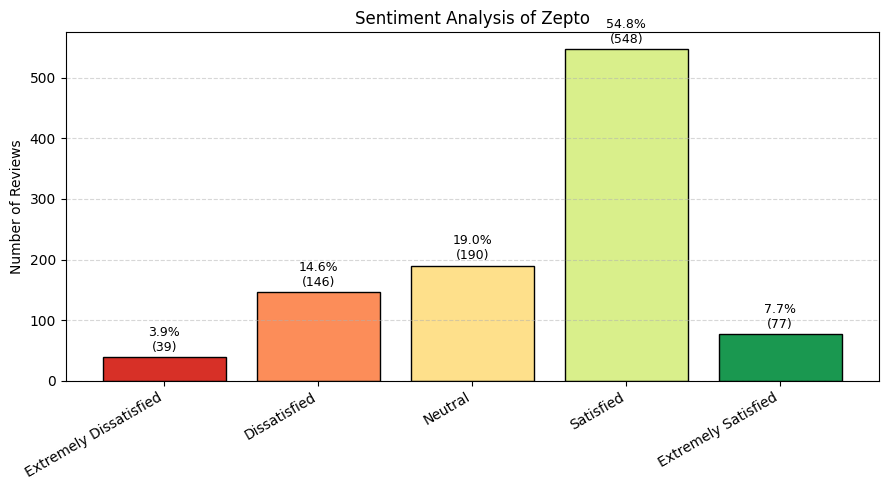

In [3]:
import matplotlib.pyplot as plt

x = ['Extremely Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Extremely Satisfied']
counts = df['Polarity Scores'].value_counts().reindex(x, fill_value=0)
y = counts.values

fig, ax = plt.subplots(figsize=(9,5))
colors = ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#1a9850']
bars = ax.bar(range(len(x)), y, color=colors, edgecolor='k')

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation=30, ha='right')
ax.set_ylabel('Number of Reviews')
ax.set_title('Sentiment Analysis of Zepto')

total = y.sum()
for bar, val in zip(bars, y):
    pct = 100 * val / total if total else 0
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(y) * 0.01, f'{pct:.1f}%\n({val})', ha='center', va='bottom', fontsize=9)

ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()